In [ ]:
import sys
import os
import warnings

sys.path.append(os.path.abspath("../scripts"))

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score, 
    precision_score, recall_score
)

from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = "retina"
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12

from data_loader import get_openml_data
from data_preprocessing import create_preprocessing_pipeline, preprocess_for_nn
from boosting_models import run_lr_tuning, run_catboost_tuning, run_lgbm_tuning
from deep_model import TabularDataset, TABMLP, train, evaluate

warnings.filterwarnings("ignore")

## Датасет [Credit-g](https://www.openml.org/search?type=data&status=active&id=31)

In [2]:
dataset_id = 31
X_train, X_valid, X_test, y_train, y_valid, y_test, categorical_indicator, attribute_names = get_openml_data(dataset_id)

In [3]:
column_transformer, categorical_features, numerical_features = create_preprocessing_pipeline(attribute_names, categorical_indicator)

In [4]:
model_lr = run_lr_tuning(X_train, y_train, X_valid, y_valid, column_transformer)
y_pred_lr = model_lr.predict(X_test)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, model_lr.predict_proba(X_test)[:, 1]))
print("F1 = %.4f" % f1_score(y_test, y_pred_lr))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred_lr))
print("Precision = %.4f" % precision_score(y_test, y_pred_lr))
print("Recall = %.4f" % recall_score(y_test, y_pred_lr))

[I 2025-04-10 16:24:16,759] A new study created in memory with name: logistic_regression_optimization
[I 2025-04-10 16:24:16,774] Trial 0 finished with value: 0.5 and parameters: {'penalty': 'l1', 'C': 0.001}. Best is trial 0 with value: 0.5.
[I 2025-04-10 16:24:16,824] Trial 1 finished with value: 0.8352380952380952 and parameters: {'penalty': 'l2', 'C': 1}. Best is trial 1 with value: 0.8352380952380952.
[I 2025-04-10 16:24:16,843] Trial 2 finished with value: 0.5 and parameters: {'penalty': 'l1', 'C': 1e-05}. Best is trial 1 with value: 0.8352380952380952.
[I 2025-04-10 16:24:16,887] Trial 3 finished with value: 0.8066666666666666 and parameters: {'penalty': 'l1', 'C': 10}. Best is trial 1 with value: 0.8352380952380952.
[I 2025-04-10 16:24:16,916] Trial 4 finished with value: 0.5 and parameters: {'penalty': 'l1', 'C': 0.01}. Best is trial 1 with value: 0.8352380952380952.
[I 2025-04-10 16:24:16,967] Trial 5 finished with value: 0.8352380952380952 and parameters: {'penalty': 'l2', '

ROC-AUC = 0.8581
F1 = 0.8758
Accuracy = 0.8100
Precision = 0.8072
Recall = 0.9571


In [5]:
model_cb = run_catboost_tuning(X_train, y_train, X_valid, y_valid, column_transformer)
y_pred_cb = model_cb.predict(X_test)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, model_cb.predict_proba(X_test)[:, 1]))
print("F1 = %.4f" % f1_score(y_test, y_pred_cb))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred_cb))
print("Precision = %.4f" % precision_score(y_test, y_pred_cb))
print("Recall = %.4f" % recall_score(y_test, y_pred_cb))

[I 2025-04-10 16:24:17,502] A new study created in memory with name: catboost_optimization
[I 2025-04-10 16:24:18,814] Trial 0 finished with value: 0.8280952380952381 and parameters: {'depth': 6, 'learning_rate': 0.03, 'l2_leaf_reg': 0.01}. Best is trial 0 with value: 0.8280952380952381.
[I 2025-04-10 16:24:28,513] Trial 1 finished with value: 0.829047619047619 and parameters: {'depth': 10, 'learning_rate': 0.3, 'l2_leaf_reg': 1.0}. Best is trial 1 with value: 0.829047619047619.
[I 2025-04-10 16:24:29,667] Trial 2 finished with value: 0.810952380952381 and parameters: {'depth': 6, 'learning_rate': 0.3, 'l2_leaf_reg': 10.0}. Best is trial 1 with value: 0.829047619047619.
[I 2025-04-10 16:24:39,463] Trial 3 finished with value: 0.8528571428571429 and parameters: {'depth': 10, 'learning_rate': 0.01, 'l2_leaf_reg': 0.1}. Best is trial 3 with value: 0.8528571428571429.
[I 2025-04-10 16:24:40,655] Trial 4 finished with value: 0.8266666666666668 and parameters: {'depth': 6, 'learning_rate': 0

ROC-AUC = 0.8257
F1 = 0.8701
Accuracy = 0.8000
Precision = 0.7976
Recall = 0.9571


In [6]:
model_lgbm = run_lgbm_tuning(X_train, y_train, X_valid, y_valid, column_transformer)
y_pred_lgbm = model_lgbm.predict(X_test)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, model_lgbm.predict_proba(X_test)[:, 1]))
print("F1 = %.4f" % f1_score(y_test, y_pred_lgbm))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred_lgbm))
print("Precision = %.4f" % precision_score(y_test, y_pred_lgbm))
print("Recall = %.4f" % recall_score(y_test, y_pred_lgbm))

[I 2025-04-10 16:26:02,055] A new study created in memory with name: lgdm_optimization
[I 2025-04-10 16:26:02,744] Trial 0 finished with value: 0.7971428571428572 and parameters: {'num_leaves': 256, 'reg_alpha': 1e-07, 'reg_lambda': 1e-08, 'learning_rate': 0.1}. Best is trial 0 with value: 0.7971428571428572.
[I 2025-04-10 16:26:03,119] Trial 1 finished with value: 0.8076190476190477 and parameters: {'num_leaves': 16, 'reg_alpha': 1e-05, 'reg_lambda': 1e-06, 'learning_rate': 0.3}. Best is trial 1 with value: 0.8076190476190477.
[I 2025-04-10 16:26:03,780] Trial 2 finished with value: 0.8061904761904761 and parameters: {'num_leaves': 64, 'reg_alpha': 1e-08, 'reg_lambda': 1e-07, 'learning_rate': 0.1}. Best is trial 1 with value: 0.8076190476190477.
[I 2025-04-10 16:26:03,995] Trial 3 finished with value: 0.830952380952381 and parameters: {'num_leaves': 4, 'reg_alpha': 1.0, 'reg_lambda': 0.001, 'learning_rate': 0.1}. Best is trial 3 with value: 0.830952380952381.
[I 2025-04-10 16:26:04,88

ROC-AUC = 0.8700
F1 = 0.8816
Accuracy = 0.8200
Precision = 0.8171
Recall = 0.9571


In [7]:
X_train, X_valid, X_test = preprocess_for_nn(X_train, X_valid, X_test, categorical_features, numerical_features)

In [8]:
trainset = TabularDataset(X_train, y_train, categorical_features)
valset = TabularDataset(X_valid, y_valid, categorical_features)
testset  = TabularDataset(X_test, y_test, categorical_features)

batch_size = 256
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(valset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(testset, batch_size=batch_size, shuffle=False)

In [9]:
cat_dims = [int(X_train[col].nunique()) for col in categorical_features]
emb_dims = [(x, min(50, (x + 1) // 2)) for x in cat_dims]

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


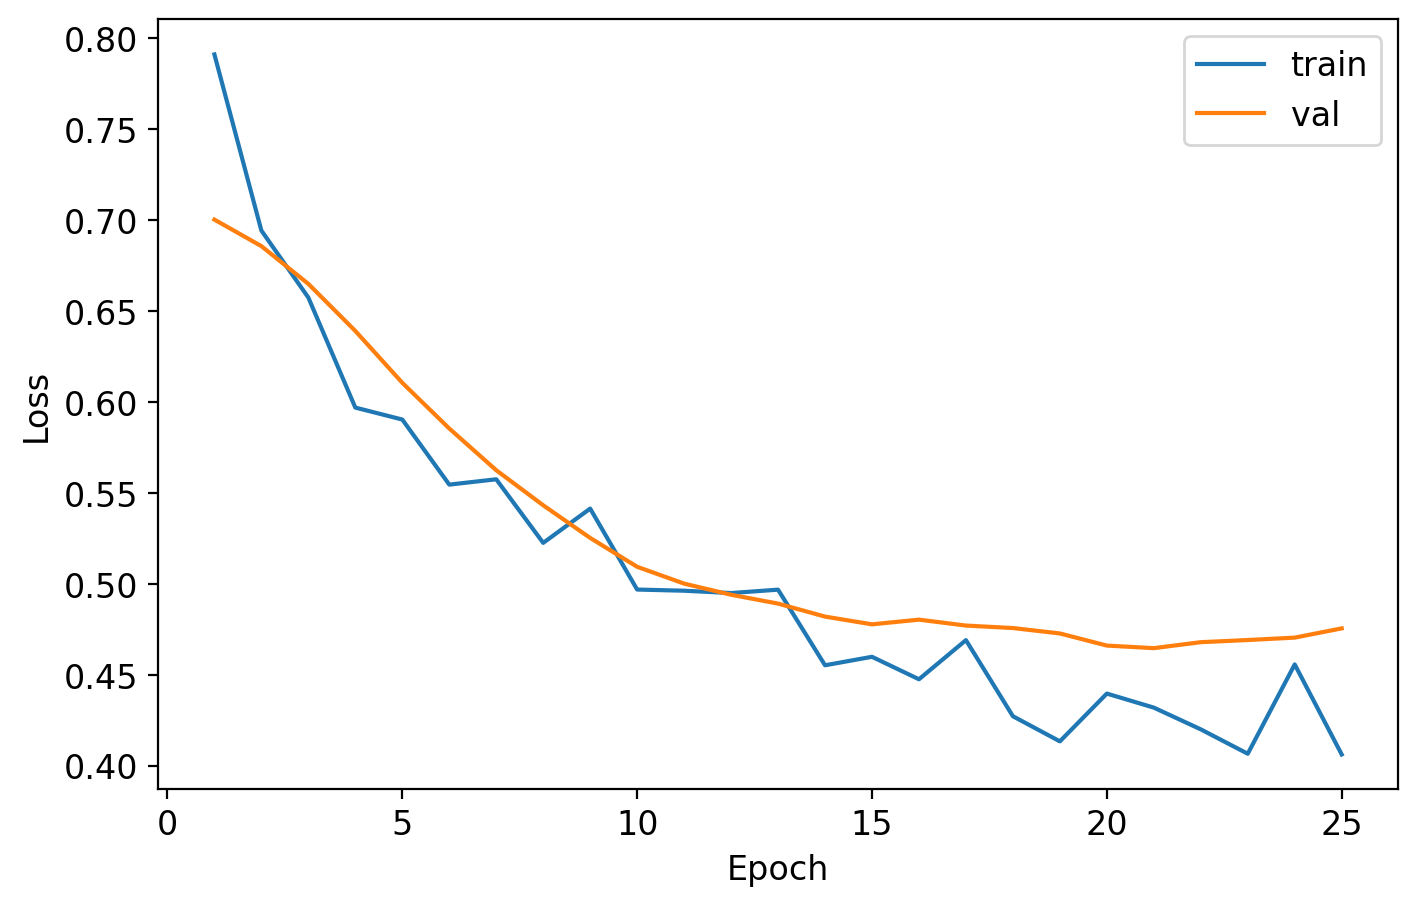

Epoch 25: train loss = 0.4063; valid loss = 0.4756


In [11]:
net = TABMLP(len(numerical_features), emb_dims).to(device)
optimizer = optim.AdamW(net.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

train(net, optimizer, 25, train_loader, val_loader, criterion, device)

In [12]:
y_true, y_prob, y_pred = evaluate(net, test_loader, device)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, y_prob))
print("F1 = %.4f" % f1_score(y_test, y_pred))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred))
print("Precision = %.4f" % precision_score(y_test, y_pred))
print("Recall = %.4f" % recall_score(y_test, y_pred))

ROC-AUC = 0.7852
F1 = 0.8533
Accuracy = 0.7800
Precision = 0.8000
Recall = 0.9143
